# Expectation & Variance

期望回答"平均是多少"，方差回答"有多散"。本课建立期望与方差的完整计算体系，并打通与积分、蒙特卡洛的联系。


## 0. 环境配置与导入


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import torch
import matplotlib

matplotlib.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Arial Unicode MS", "Microsoft YaHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

print("PyTorch version:", torch.__version__)
torch.manual_seed(42)


PyTorch version: 2.13.0


## 1. 期望：概率加权平均


离散：$\mathbb{E}[X] = \sum_x x\,p(x)$；连续：$\mathbb{E}[X] = \int x\,p(x)\,dx$（calculus 07 已见）。

期望是**线性算子**（核心性质）：

$$\mathbb{E}[aX + bY + c] = a\,\mathbb{E}[X] + b\,\mathbb{E}[Y] + c$$

对任意两个随机变量成立，**不需要独立**。证明（离散情形）：$\sum_x (ax+by+c)p(x) = a\sum x p(x) + b\sum y p(y) + c$。


In [2]:
rng = np.random.default_rng(0)
X = rng.standard_normal(200000)
Y = rng.standard_normal(200000)

print(f"E[3X - 2Y + 5] ≈ {np.mean(3*X - 2*Y + 5):.4f}（解析 5）")
print(f"E[X] ≈ {np.mean(X):.4f}（解析 0）")
print("线性性质对任意 X, Y 成立，不需要独立")


E[3X - 2Y + 5] ≈ 5.0000（解析 5）
E[X] ≈ 0.0001（解析 0）
线性性质对任意 X, Y 成立，不需要独立


## 2. 方差：偏离期望的平方均值


$$\mathrm{Var}[X] = \mathbb{E}\big[(X-\mu)^2\big] = \mathbb{E}[X^2] - (\mathbb{E}[X])^2$$

**推导**：展开 $(X-\mu)^2 = X^2 - 2\mu X + \mu^2$，取期望用线性性质即得。标准差 $\sigma = \sqrt{\mathrm{Var}[X]}$。

方差衡量分散程度，是深度学习中"梯度噪声大小"的度量。


In [3]:
print(f"Var[X]  公式1 E[(X-μ)²] = {np.mean((X - X.mean())**2):.4f}")
print(f"Var[X]  公式2 E[X²]-E[X]² = {np.mean(X**2) - np.mean(X)**2:.4f}（解析 1）")

# 方差与尺度：Var[aX] = a²Var[X]
print(f"Var[3X] = {np.var(3*X):.4f}（解析 9）")


Var[X]  公式1 E[(X-μ)²] = 1.0024
Var[X]  公式2 E[X²]-E[X]² = 1.0024（解析 1）
Var[3X] = 9.0216（解析 9）


## 3. 常见分布的期望与方差


| 分布 | $\mathbb{E}[X]$ | $\mathrm{Var}[X]$ |
|------|------|------|
| 伯努利 $p$ | $p$ | $p(1-p)$ |
| 二项 $B(n,p)$ | $np$ | $np(1-p)$ |
| 泊松 $P(\lambda)$ | $\lambda$ | $\lambda$ |
| 均匀 $U(a,b)$ | $(a+b)/2$ | $(b-a)^2/12$ |
| 指数 $\mathrm{Exp}(\lambda)$ | $1/\lambda$ | $1/\lambda^2$ |
| 正态 $N(\mu,\sigma^2)$ | $\mu$ | $\sigma^2$ |

注意泊松的均值=方差、指数的均值=标准差——这些"巧合"是分布身份的线索。蒙特卡洛验证：


In [4]:
def mc_check(name, sampler, mean, var, n=300000):
    s = sampler(n)
    print(f"{name:<12} E≈{s.mean():.4f}（{mean:.4f}）  Var≈{s.var():.4f}（{var:.4f}）")

mc_check("二项 B(10,0.3)",
         lambda n: rng.binomial(10, 0.3, n), 3.0, 2.1)
mc_check("泊松 P(4)",
         lambda n: rng.poisson(4, n), 4.0, 4.0)
mc_check("均匀 U(-2,4)",
         lambda n: rng.uniform(-2, 4, n), 1.0, 3.0)
mc_check("指数 Exp(0.5)",
         lambda n: rng.exponential(1/0.5, n), 2.0, 4.0)
mc_check("正态 N(1, 9)",
         lambda n: rng.normal(1, 3, n), 1.0, 9.0)


二项 B(10,0.3) E≈3.0054（3.0000）  Var≈2.1040（2.1000）
泊松 P(4)      E≈4.0058（4.0000）  Var≈4.0049（4.0000）
均匀 U(-2,4)   E≈0.9996（1.0000）  Var≈2.9981（3.0000）
指数 Exp(0.5)  E≈1.9974（2.0000）  Var≈3.9781（4.0000）
正态 N(1, 9)   E≈0.9958（1.0000）  Var≈8.9910（9.0000）


## 4. 协方差与相关系数：两个变量如何一起变


$$\mathrm{Cov}(X,Y) = \mathbb{E}\big[(X-\mu_X)(Y-\mu_Y)\big], \qquad \rho = \frac{\mathrm{Cov}(X,Y)}{\sigma_X\sigma_Y} \in [-1, 1]$$

- $\rho > 0$：同向变化；$\rho < 0$：反向；$\rho \approx 0$：线性无关
- 相关系数消除了量纲，是协方差的"标准化"版本

先看直觉，第 04 课系统展开协方差矩阵。


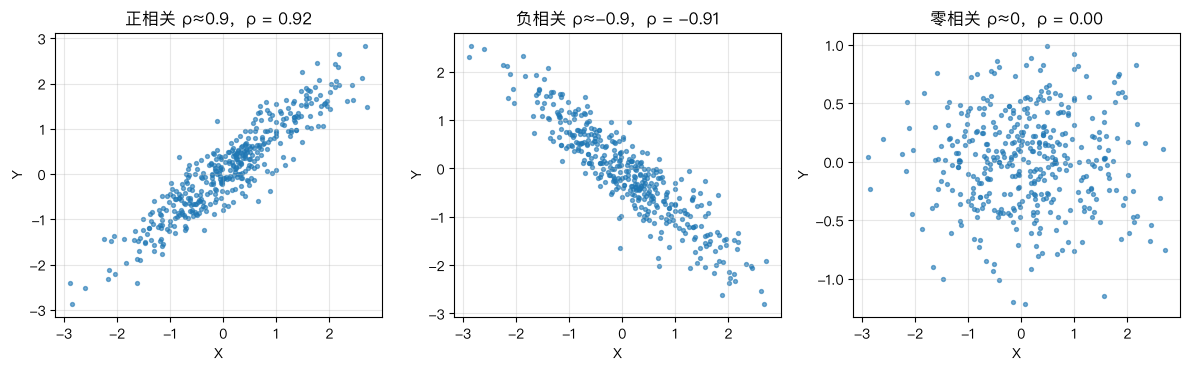

In [5]:
xs = rng.standard_normal(400)
cases = [
    ('正相关 ρ≈0.9',  xs,           0.9*xs + 0.4*rng.standard_normal(400)),
    ('负相关 ρ≈-0.9', xs,          -0.9*xs + 0.4*rng.standard_normal(400)),
    ('零相关 ρ≈0',    xs,           0.4*rng.standard_normal(400)),
]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, (title, a, b) in zip(axes, cases):
    ax.scatter(a, b, s=8, alpha=0.6)
    ax.set_title(f'{title}，ρ = {np.corrcoef(a, b)[0,1]:.2f}')
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.grid(alpha=0.3)
plt.tight_layout()


## 5. 期望在机器学习中的角色


- **风险 = 期望损失**：$L(w) = \mathbb{E}_{(x,y)\sim P}\,\ell(x,y;w)$，训练就是在最小化一个期望（calculus 08 已见）
- **梯度是期望**：mini-batch 梯度是期望梯度的蒙特卡洛估计，方差随 batch 增大而减小（呼应 calculus 06）
- **偏差-方差**：模型的泛化误差可以分解为偏差² + 方差 + 噪声（nn-core 07 课完整推导）


## 课后练习


1. **证明**：$\mathrm{Var}[aX+b] = a^2\mathrm{Var}[X]$（从定义出发）。
2. **证明**：$\mathrm{Var}[X+Y] = \mathrm{Var}[X]+\mathrm{Var}[Y]+2\mathrm{Cov}(X,Y)$，并指出独立时退化为加法。
3. **蒙特卡洛**：验证 $E[\sin X] \ne \sin(E[X])$（$X \sim N(0,1)$），体会"期望不能穿过非线性"。
4. **应用**：写出 $\mathrm{Cov}(X,X)$ 与 $\mathrm{Var}[X]$ 的关系。
5. **思考**：为什么 mini-batch 越大，梯度估计的方差越小？（提示：$\mathrm{Var}[\bar{X}_n] = \sigma^2/n$）
